# How to derive a survival curve from a base cruve and hazard ratio

## Introduction

In rare disease modelling, analysts often face a common challenge: how to derive survival curves when only limited evidence is available.

In the notebook, I share a step-by-step guide to deriving survival curves from a base-case curve using hazard ratios. This approach can be particularly useful when direct survival data for new treatments or scenarios are unavailable.

The method was applied and validated in a real-world project where evidence gaps required careful modelling assumptions.

## Load modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## Input data

### Base survival curve

In [3]:
# --- Create a table contains age from 0 to 50 years, and cumulative survival proportion at each age ---

# Create age range from 0 to 50 years
ages = np.arange(0, 51)


# Create a hypothetical cumulative survival proportion for each age using an exponential decay function
# This is just an example and can be replaced with actual data
base_survival = np.exp(-0.05 * ages)


# Create a DataFrame to hold the age and cumulative survival data
base_survival_df = pd.DataFrame({
    'Age': ages,
    'Base_survival': base_survival
})

In [4]:
# Inspect the first few rows of the DataFrame
print(base_survival_df.head())

   Age  Base_survival
0    0       1.000000
1    1       0.951229
2    2       0.904837
3    3       0.860708
4    4       0.818731


### Hazard ratio

In [5]:
# Hazard ratio (Example hazard ratio for the new treatment compared to the base case)
hazard_ratio = 0.5

## Output survival curve

### Calculate base curve hazard

In [6]:
# Convert cumulative survival to hazard
next_survival = base_survival_df['Base_survival'].shift(-1)

# Calculate the hazard for the base case
base_hazard = -np.log(next_survival / base_survival_df['Base_survival'])

# Save base_hazard to the DataFrame
base_survival_df['Base_hazard'] = base_hazard

# Inspect the first few rows of the DataFrame with hazard
print(base_survival_df.head())

   Age  Base_survival  Base_hazard
0    0       1.000000         0.05
1    1       0.951229         0.05
2    2       0.904837         0.05
3    3       0.860708         0.05
4    4       0.818731         0.05


### Calculate target curve hazard

In [ ]:
# Calculate the target hazard using the hazard ratio
base_survival_df['Target_hazard'] = base_survival_df['Base_hazard'] * hazard_ratio

### Inform the target curve survival

In [8]:
initial_target_survival = base_survival_df['Base_survival'][0]  # Assuming the initial survival is the same as the base case

In [13]:
# Row count for iteration
row_count = base_survival_df.shape[0]

# Calculate the target survival curve using the target hazard
target_survival = [initial_target_survival]  # Start with the initial survival
for i in range(1, row_count):
    # Calculate the next survival based on the previous survival and the target hazard
    next_survival = target_survival[-1] * np.exp(-base_survival_df['Target_hazard'][i])
    target_survival.append(next_survival)

# Add the target survival to the DataFrame
base_survival_df['Target_survival'] = target_survival

# Format values across all columns to 2 decimal places
base_survival_df = base_survival_df.round(2)

# Inspect the first few rows of the DataFrame with target survival
print(base_survival_df.head())

   Age  Base_survival  Base_hazard  Target_hazard  Target_survival
0    0           1.00         0.05           0.02             1.00
1    1           0.95         0.05           0.03             0.98
2    2           0.90         0.05           0.02             0.95
3    3           0.86         0.05           0.02             0.93
4    4           0.82         0.05           0.02             0.90


In [14]:
# Save the DataFrame to a CSV file
base_survival_df.to_csv('survival_curves.csv', index=False)

## Visualization

Create two curves for comparison of base- and target survival.

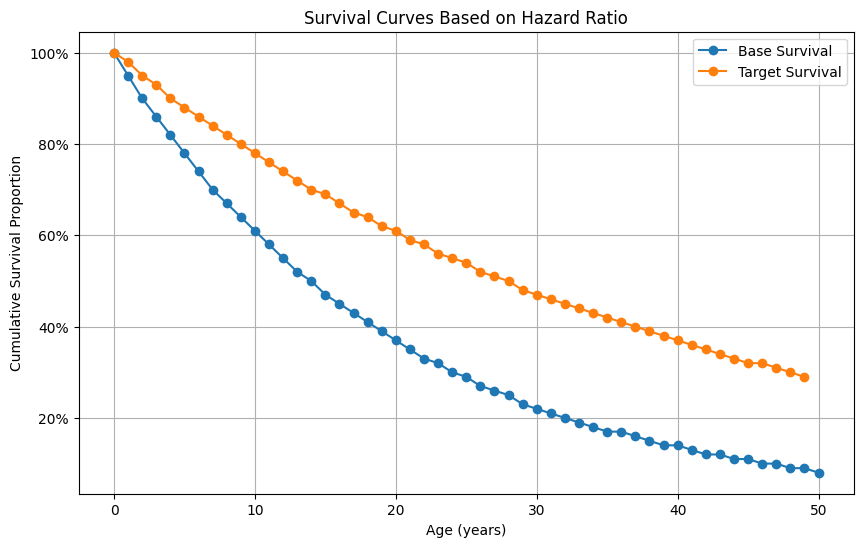

In [16]:
# Create a plot to visualize the base and target survival curves
plt.figure(figsize=(10, 6)) # Set the figure size for better visibility

# Markers are added to the plot for better visibility of data points
plt.plot(base_survival_df['Age'], base_survival_df['Base_survival'], label='Base Survival', marker='o') 
plt.plot(base_survival_df['Age'], base_survival_df['Target_survival'], label='Target Survival', marker='o')

# Set % format for y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Add title and labels to the plot
plt.title('Survival Curves Based on Hazard Ratio')
plt.xlabel('Age (years)')
plt.ylabel('Cumulative Survival Proportion')
plt.legend()
plt.grid()

plt.show()